In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
magic_gamma_telescope = fetch_ucirepo(id=159)

# data (as pandas dataframes)
X = magic_gamma_telescope.data.features
y = magic_gamma_telescope.data.targets

# metadata
print(magic_gamma_telescope.metadata)

# variable information
print(magic_gamma_telescope.variables)



{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

Број и имиња на класи: 2 ['gamma', 'hadron']
Број на атрибути: 10
            fLength        fWidth         fSize         fConc        fConc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

              fAsym       fM3Long      fM3Trans        fAlpha         fDist  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      -4.331745     10.545545      0.249726     27.645707   

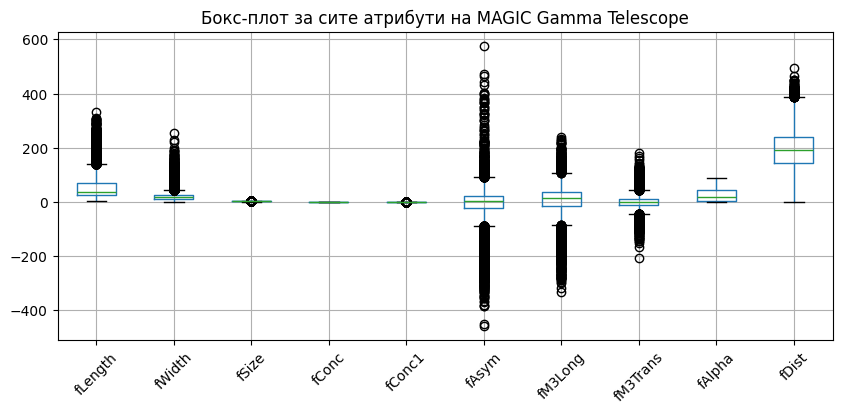

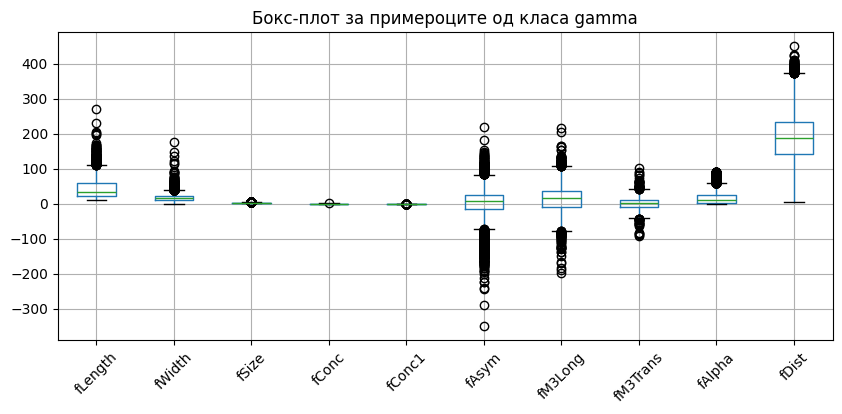

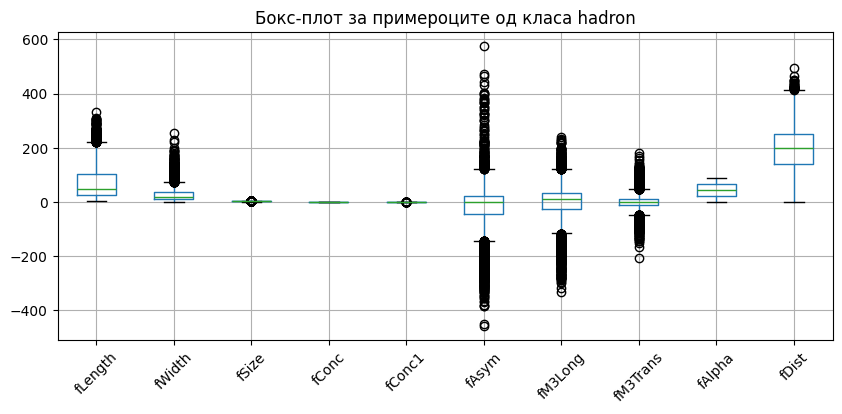

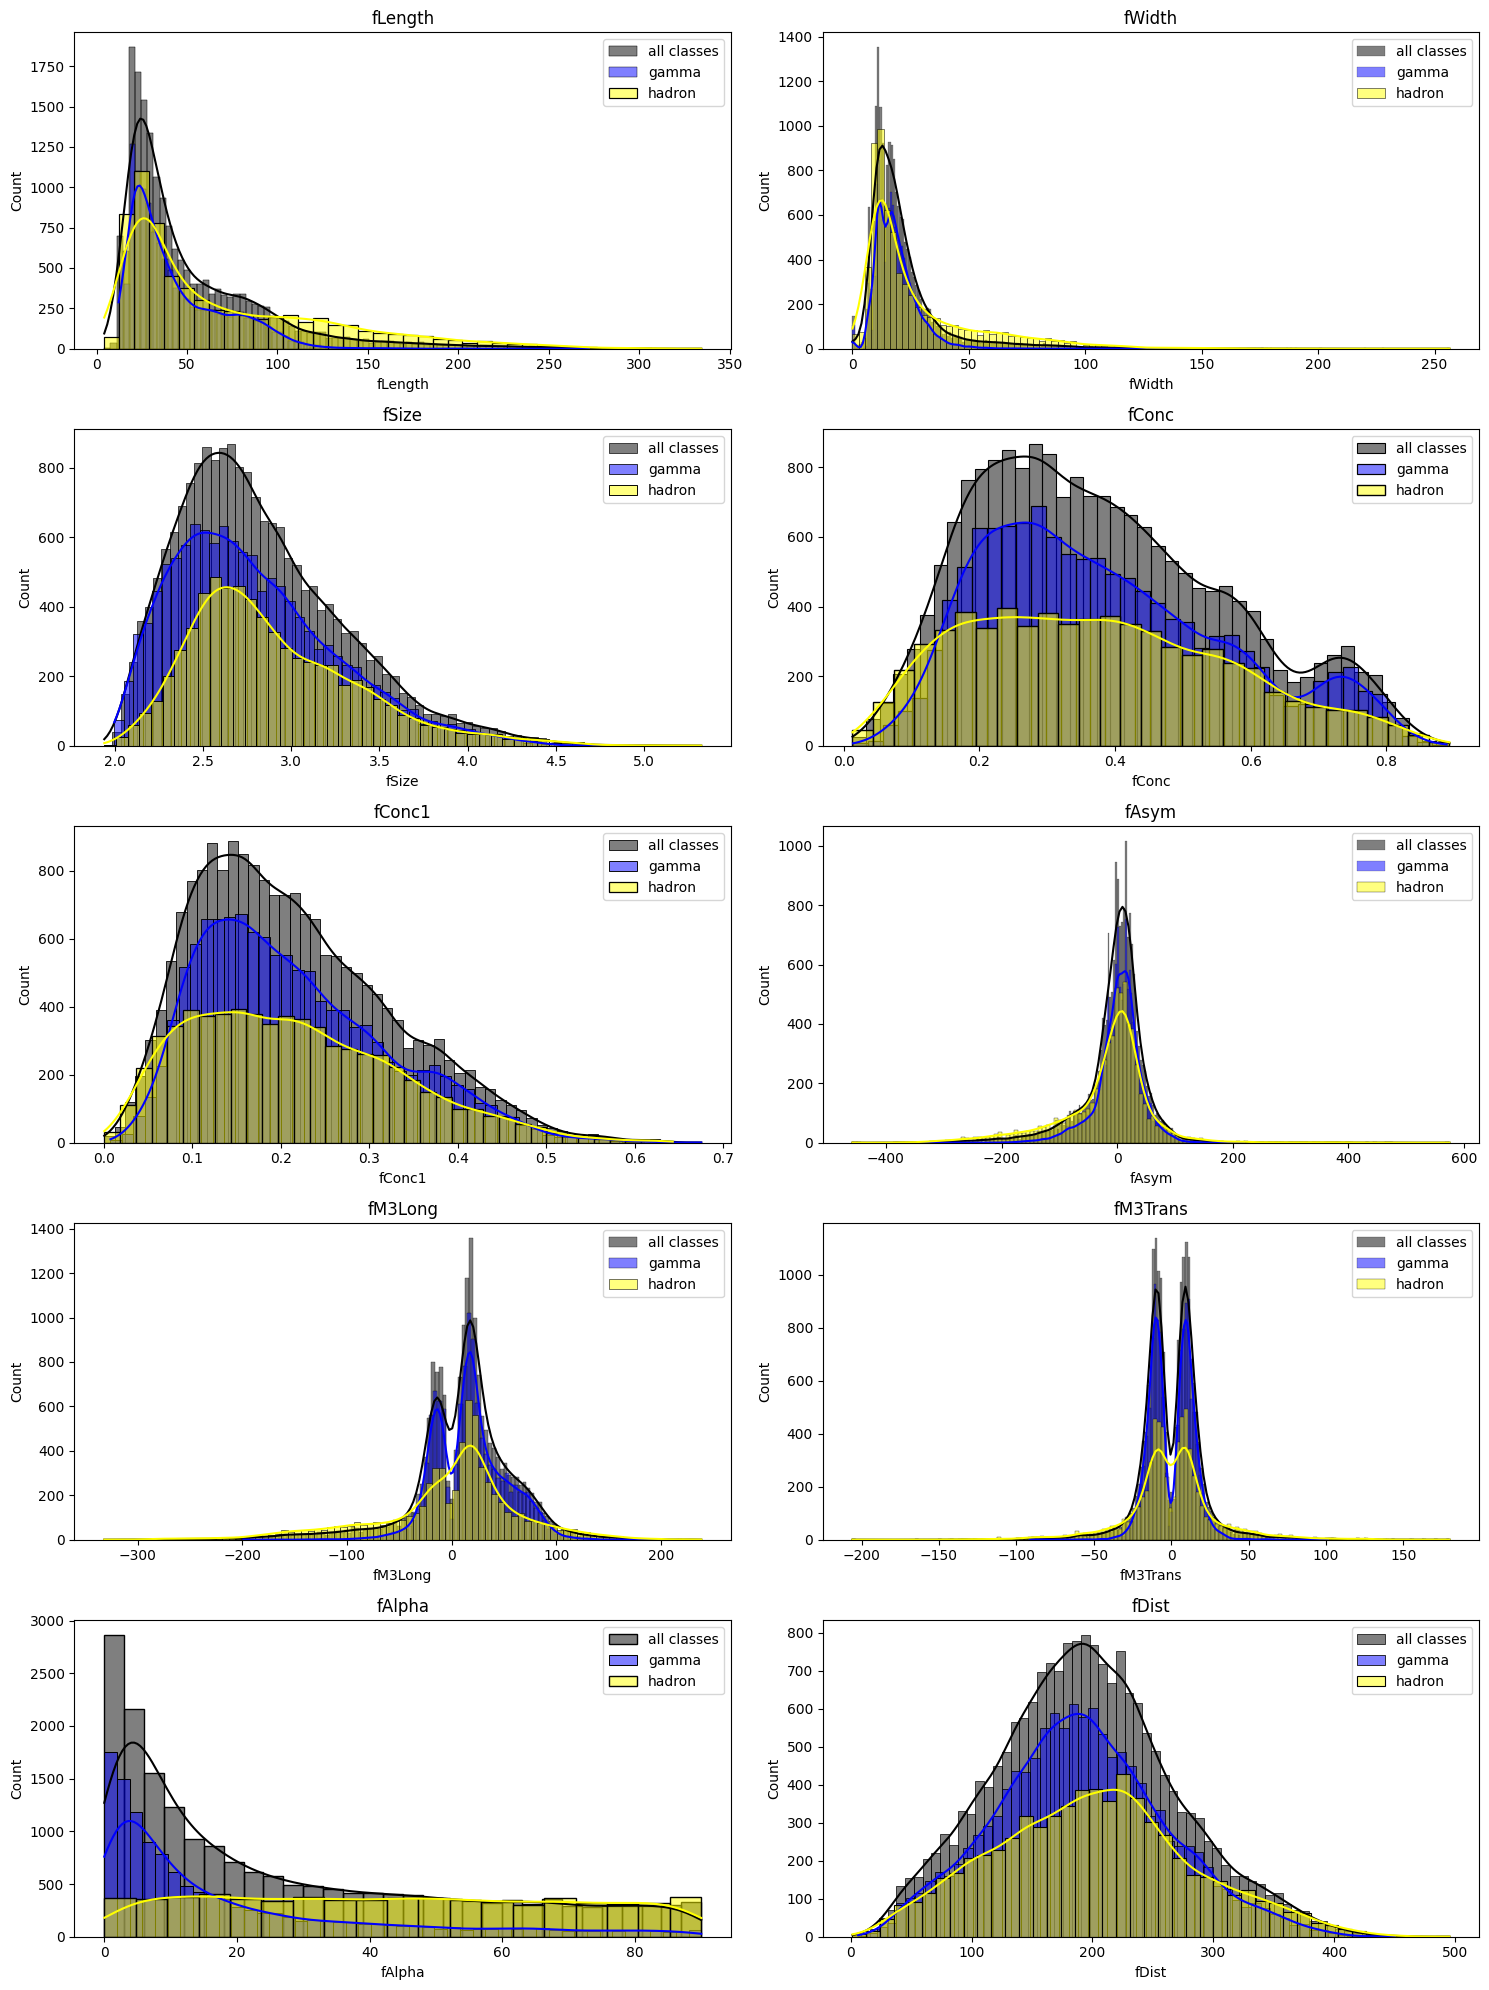

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


feature_names = X.columns.tolist()
target_names = ['gamma', 'hadron'] # 'g' и 'h'
number_of_features = len(feature_names)
number_of_classes = len(target_names)

y_numeric = y.iloc[:, 0].map({'g': 0, 'h': 1}).values


df = X.copy()
df['target'] = y_numeric

print(f"Број и имиња на класи: {number_of_classes} {target_names}")
print(f"Број на атрибути: {number_of_features}")


print(df.describe())
print(df.isnull().sum())
print(df.value_counts("target"))


fig = plt.figure(figsize=(10, 4))
df.drop(['target'], axis=1).boxplot()
plt.title('Бокс-плот за сите атрибути на MAGIC Gamma Telescope')
plt.xticks(rotation=45)
plt.show()


for i in range(number_of_classes):
    fig = plt.figure(figsize=(10, 4))
    df[df.target == i].drop(['target'], axis=1).boxplot()
    plt.title(f'Бокс-плот за примероците од класа {target_names[i]}')
    plt.xticks(rotation=45)
    plt.show()


colors = ['blue', 'yellow']
plt.figure(figsize=(15, 20))
for feature in range(number_of_features):
    ax = plt.subplot(5, 2, feature + 1)
    plt.title(feature_names[feature])

    sns.histplot(X.iloc[:, feature], color='black', label='all classes', kde=True, stat="count")

    for Class in range(number_of_classes):
        sns.histplot(X.iloc[y_numeric == Class, feature], color=colors[Class],
                     label=target_names[Class], kde=True, stat="count")
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.3, random_state=42)


models = {
    "Naïve Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}

results = {}


for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} точност: {acc:.4f}")


Naïve Bayes точност: 0.7275
LDA точност: 0.7872
QDA точност: 0.7855


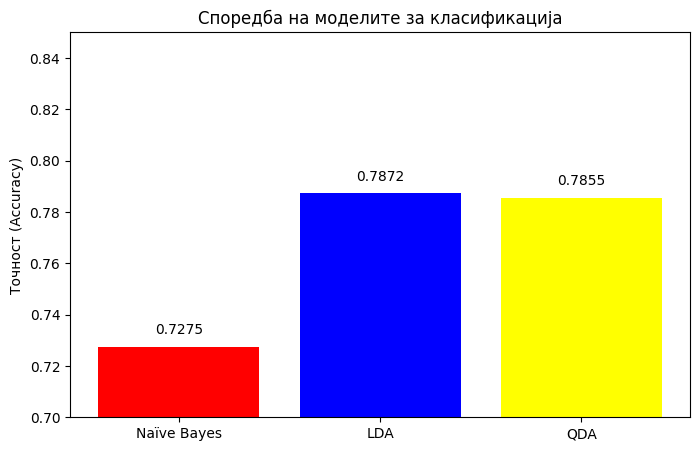

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['red', 'blue', 'yellow'])
plt.ylabel('Точност (Accuracy)')
plt.title('Споредба на моделите за класификација')
plt.ylim(0.7, 0.85)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()